In [380]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import pandas as pd
from scipy.ndimage import gaussian_filter1d
import glob
import re as re
from scipy.interpolate import RectBivariateSpline
import matplotlib as mpl
import matplotlib.ticker as ticker
from matplotlib.ticker import AutoMinorLocator
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches

mpl.rcParams['font.family'] = 'Serif'


c = 299792.458
f0 = 1420.40575
plt_long=0
sigma=1.75
thresh=.45


In [381]:

# ── Astronomy dark theme ──────────────────────────────────────────────────────
DARK_BG    = "#0d1117"
PANEL_BG   = "#161b22"
GRID_COLOR = "#30363d"
TEXT_COLOR = "#e6edf3"
MUTED      = "#8b949e"

RAW_C      = "#4a9eff"   # soft blue  – raw intensity
SMOOTH_C   = "#ffffff"   # white      – smoothed
THRESH_C   = "#f0a04b"   # amber      – threshold
BASE_C     = "#3fb950"   # green      – baseline
PEAK_C     = "#ff6b6b"   # coral red  – peak / bounds
SPAN_C     = "#f0a04b"   # amber fill – signal region
SNR_C      = "#bf91f3"   # lavender   – SNR trace
SNR_FILL   = "#3fb950"   # green fill – above-sigma
plt.rcParams.update({
    'figure.facecolor':  DARK_BG,
    'axes.facecolor':    PANEL_BG,
    'text.color':        TEXT_COLOR,
    'axes.labelcolor':   MUTED,
    'axes.edgecolor':    GRID_COLOR,
    'xtick.color':       TEXT_COLOR,
    'ytick.color':       TEXT_COLOR,
    'legend.framealpha': 0.25,
    'legend.edgecolor':  GRID_COLOR,
    'legend.labelcolor': TEXT_COLOR,
    'legend.fontsize':   9,
    'axes.labelsize':    11,
    'grid.color':        GRID_COLOR,
    'grid.linewidth':    0.6,
    'grid.alpha':        0.8,
})



def _style_ax(ax, title):
    """Apply shared dark-theme styling to one axes."""
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=TEXT_COLOR, which='both', labelsize=10)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COLOR)
    ax.grid(which='major', color=GRID_COLOR, linewidth=0.6, alpha=0.8)
    ax.grid(which='minor', color=GRID_COLOR, linewidth=0.3, alpha=0.4)
    ax.set_title(title, color=TEXT_COLOR, fontsize=13, fontweight='bold',
                 fontfamily='monospace', pad=8)
    ax.xaxis.label.set_color(MUTED)
    ax.yaxis.label.set_color(MUTED)


def triple_plot(intensity, cutoff_freq_low, cutoff_freq_high, noise, long,
                peak_freq, smooth, threshold, noise_median, freq):

    plt.rcParams.update({
        'figure.facecolor':  DARK_BG,
        'text.color':        TEXT_COLOR,
        'axes.labelsize':    11,
        'axes.labelcolor':   MUTED,
        'legend.framealpha': 0.25,
        'legend.edgecolor':  GRID_COLOR,
        'legend.labelcolor': TEXT_COLOR,
        'legend.fontsize':   9,
    })

    fig = plt.figure(figsize=(13, 11))
    fig.patch.set_facecolor(DARK_BG)

    # Tighter vertical spacing, room for a super-title
    gs = gridspec.GridSpec(3, 1, figure=fig, hspace=0.42,
                           top=0.93, bottom=0.07, left=0.09, right=0.97)
    axes = [fig.add_subplot(gs[i]) for i in range(3)]

    # ── Shared signal-region helper ───────────────────────────────────────────
    def _draw_signal_region(ax):
        if cutoff_freq_low is not None and cutoff_freq_high is not None:
            lo = min(cutoff_freq_low, cutoff_freq_high)
            hi = max(cutoff_freq_low, cutoff_freq_high)
            ax.axvspan(lo, hi, alpha=0.12, color=SPAN_C, zorder=1)
            ax.axvline(lo, color=PEAK_C, linestyle='--', linewidth=1.5,
                       label=f"Edge: {lo:.3f} MHz", zorder=3)
            ax.axvline(hi, color=PEAK_C, linestyle=':',  linewidth=1.5,
                       label=f"Peak: {hi:.3f} MHz", zorder=3)

    # ── Panel 1 – Full HI Spectrum ────────────────────────────────────────────
    ax1 = axes[0]
    _style_ax(ax1, "Full HI Spectrum")

    ax1.plot(freq, intensity, color=RAW_C,   linewidth=0.8, alpha=0.6,
             label="Raw intensity", zorder=2)
    ax1.plot(freq, smooth,    color=SMOOTH_C, linewidth=1.8,
             label="Smoothed", zorder=3)
    ax1.axhline(threshold,   color=THRESH_C, linestyle='--', linewidth=1.6,
                label=f"Threshold  {threshold:.2f} K", zorder=3)
    ax1.axhline(noise_median, color=BASE_C,   linestyle=':',  linewidth=1.3,
                label=f"Baseline  {noise_median:.2f} K", zorder=3)
    _draw_signal_region(ax1)

    ax1.set_xlabel("Frequency (MHz)")
    ax1.set_ylabel("Intensity (K)")
    ax1.legend(loc='upper left', ncol=2)

    # ── Panel 2 – Zoomed HI Window ────────────────────────────────────────────
    ax2 = axes[1]
    _style_ax(ax2, "Zoomed HI Region  (1418 – 1423 MHz)")

    hi_mask = (freq >= 1418) & (freq <= 1423)
    ax2.plot(freq[hi_mask], intensity[hi_mask], color=RAW_C,    linewidth=0.9,
             alpha=0.6, label="Raw intensity", zorder=2)
    ax2.plot(freq[hi_mask], smooth[hi_mask],    color=SMOOTH_C, linewidth=2.2,
             label="Smoothed", zorder=3)
    ax2.axhline(threshold,    color=THRESH_C, linestyle='--', linewidth=1.6,
                label=f"Threshold  {threshold:.2f} K")
    ax2.axhline(noise_median, color=BASE_C,   linestyle=':',  linewidth=1.3,
                label=f"Baseline  {noise_median:.2f} K")

    if cutoff_freq_low is not None and cutoff_freq_high is not None:
        lo = min(cutoff_freq_low, cutoff_freq_high)
        hi = max(cutoff_freq_low, cutoff_freq_high)
        ax2.axvspan(lo, hi, alpha=0.12, color=SPAN_C)
        ax2.axvline(lo, color=PEAK_C, linestyle='--', linewidth=1.5,
                    label=f"Edge: {lo:.3f} MHz", zorder=3)
    if peak_freq is not None:
        ax2.axvline(peak_freq, color=PEAK_C, linestyle=':',  linewidth=2,
                    label=f"Peak: {peak_freq:.3f} MHz", zorder=4)

    ax2.set_xlabel("Frequency (MHz)")
    ax2.set_ylabel("Intensity (K)")
    ax2.legend(loc='upper left', ncol=2)

    # ── Panel 3 – SNR ─────────────────────────────────────────────────────────
    ax3 = axes[2]
    _style_ax(ax3, "Signal-to-Noise Ratio")

    snr = (smooth - noise_median) / noise
    ax3.plot(freq, snr, color=SNR_C, linewidth=1.6, label="SNR", zorder=3)
    ax3.axhline(0,     color=MUTED,    linestyle='-',  linewidth=0.6, zorder=2)
    ax3.axhline(sigma, color=THRESH_C, linestyle='--', linewidth=1.6,
                label=f"{sigma}σ threshold", zorder=3)
    ax3.fill_between(freq, 0, snr, where=(snr > sigma),
                     alpha=0.25, color=SNR_FILL, label="Above threshold", zorder=1)

    if peak_freq is not None:
        ax3.axvline(peak_freq, color=PEAK_C, linestyle=':',  linewidth=2,
                    label=f"Peak: {peak_freq:.3f} MHz", zorder=4)
    if cutoff_freq_low is not None:
        ax3.axvline(cutoff_freq_low, color=PEAK_C, linestyle='--', linewidth=1.5,
                    label=f"Edge: {cutoff_freq_low:.3f} MHz", zorder=4)

    ax3.set_xlabel("Frequency (MHz)")
    ax3.set_ylabel("SNR  (σ)")
    ax3.legend(loc='upper left', ncol=2)

    # ── Super-title ───────────────────────────────────────────────────────────
    fig.suptitle("HI 21 cm Spectral Analysis Longitude "+str(long), color=TEXT_COLOR,
                 fontsize=16, fontweight='bold', fontfamily='monospace', y=0.975)

    plt.savefig(f'Images/FreqExtract{long}.png', dpi=300,
                bbox_inches='tight', facecolor=DARK_BG)
    plt.show()

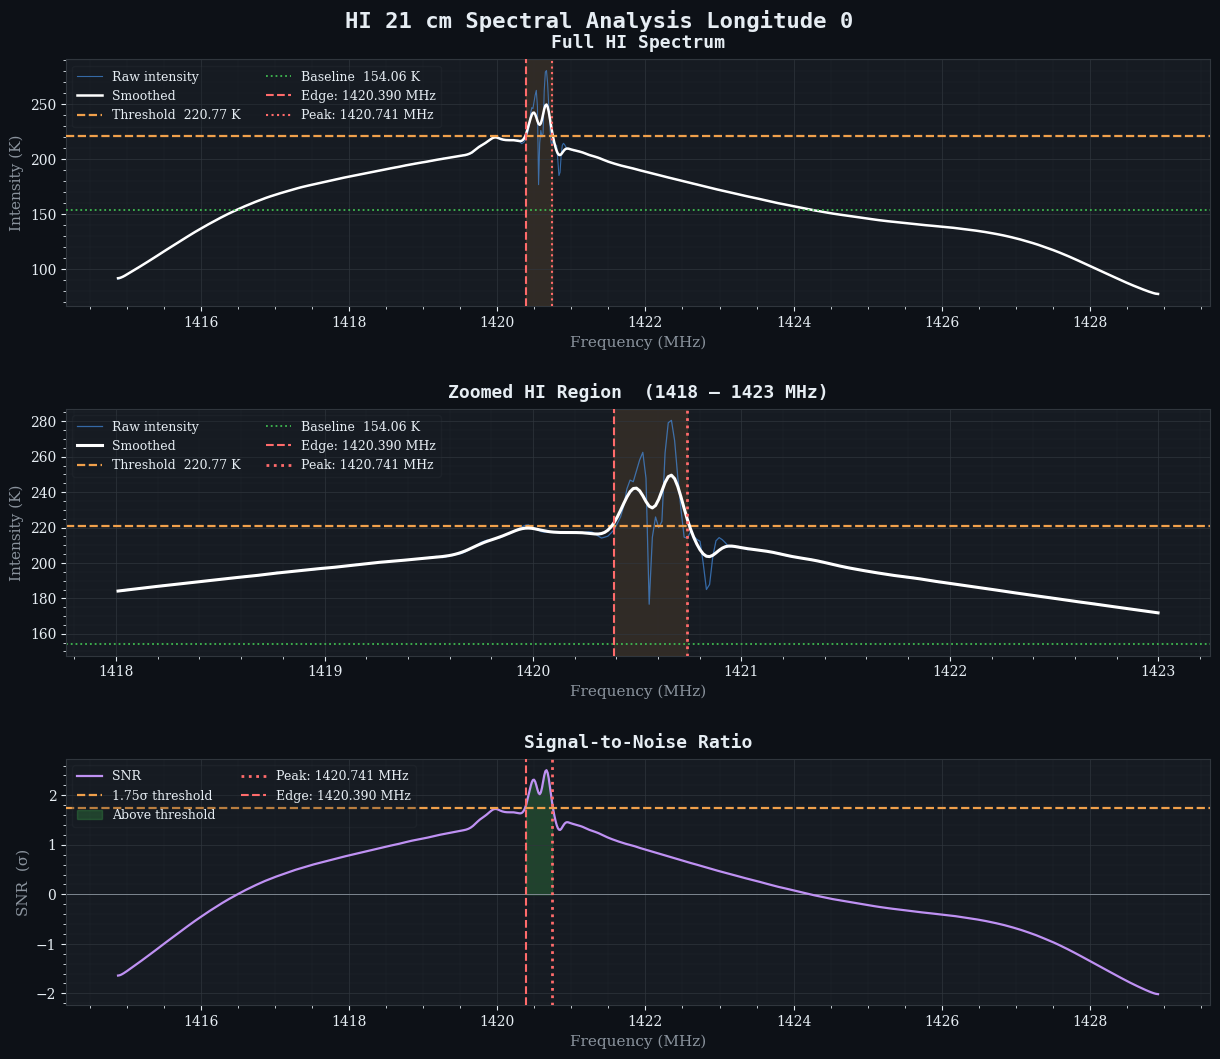

In [ ]:


path="SkynetFiles"

files = sorted(glob.glob(f"{path}/*.cal.txt"))
highest_freq_df=pd.DataFrame(columns=['Longitude','Highest_freq'])
highest_freq_df['Longitude']=[i for i in range(91)]
highest_freq_df.drop(64,inplace=True)
dfs=[]
long=[]
for f in files:
    # extract longitude from filename
    m = re.search(r"GLONG[_-](\d+)", f)
    lon = int(m.group(1))
    long.append(lon)

    # load data
    data = np.loadtxt(f, comments="#")
    freq = data[:, 0]
    xx = data[:, 1]
    yy = data[:, 2]
    I = (xx + yy) / 2.0

    # compute velocity axis (same for all files)
    vel = c * (f0 - freq) / f0

    # build a DataFrame for this file
    df = pd.DataFrame({
        "Frequency": freq,
        "Velocity": vel,
        lon: I
    })
    dfs.append(df)

    if lon >16:
        thresh=.40
        sigma=3
    else:
        thresh=.45
        sigma=1.75
        
    # Smooth the spectrum
    smooth = gaussian_filter1d(I, 3)

    # Estimate noise from edge regions (first and last 40%)
    n_edge = int(len(smooth) * thresh)
    edge_data = np.concatenate([smooth[:n_edge], smooth[-n_edge:]])
    noise_median = np.median(edge_data)
    noise_std = np.std(edge_data)
    

    # Set threshold at 3-sigma above baseline
    threshold = noise_median + sigma * noise_std

    # Find highest frequency above threshold
    # (Frequencies are descending, so first position = highest freq)
    above_noise = smooth > threshold
    positions = np.where(above_noise)[0]
    cutoff_freq_low=freq[positions[-1]]
    cutoff_freq_high=freq[positions[0]]
    peak_freq=cutoff_freq_high
    noise = np.std(edge_data)

    if len(positions) > 0:
        highest_freq_df.loc[highest_freq_df['Longitude']==lon,'Highest_freq']=freq[positions[-1]]
    if (lon==plt_long):
        triple_plot(I,cutoff_freq_low,cutoff_freq_high,noise,lon,peak_freq,smooth,threshold,noise_median,freq)
        
   

temp = dfs[0]

for df in dfs[1:]:
    temp = temp.merge(df, on=["Frequency","Velocity"], how="outer")

temp = temp[['Frequency','Velocity']+[i for i in range(0,64)]+[i for i in range(65,91)]]




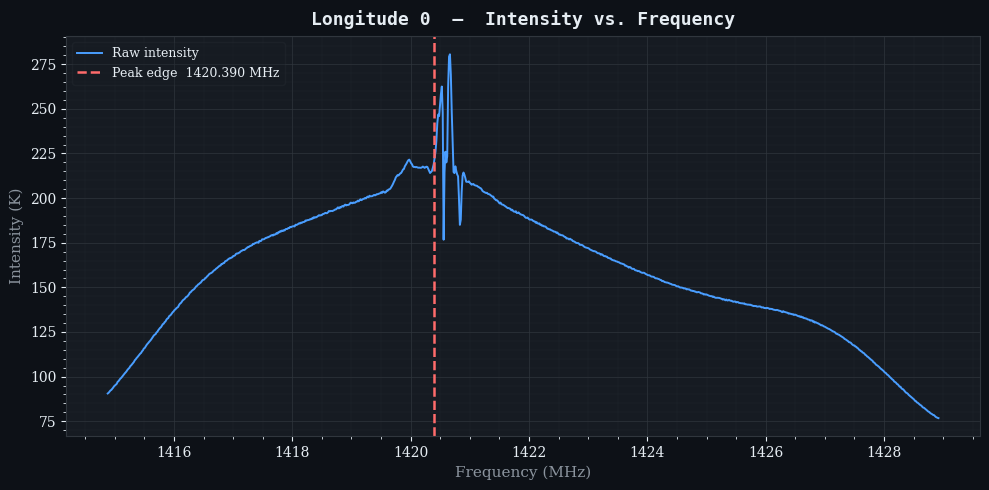

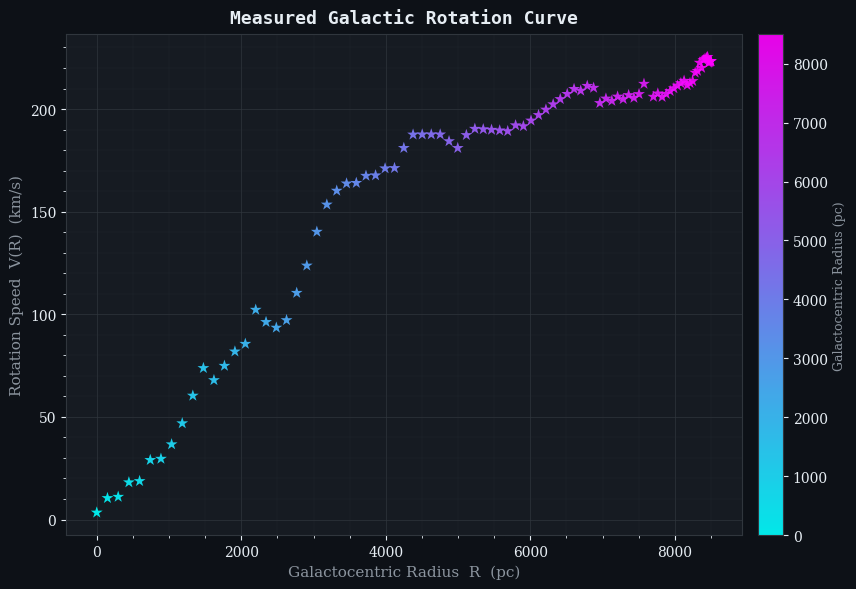

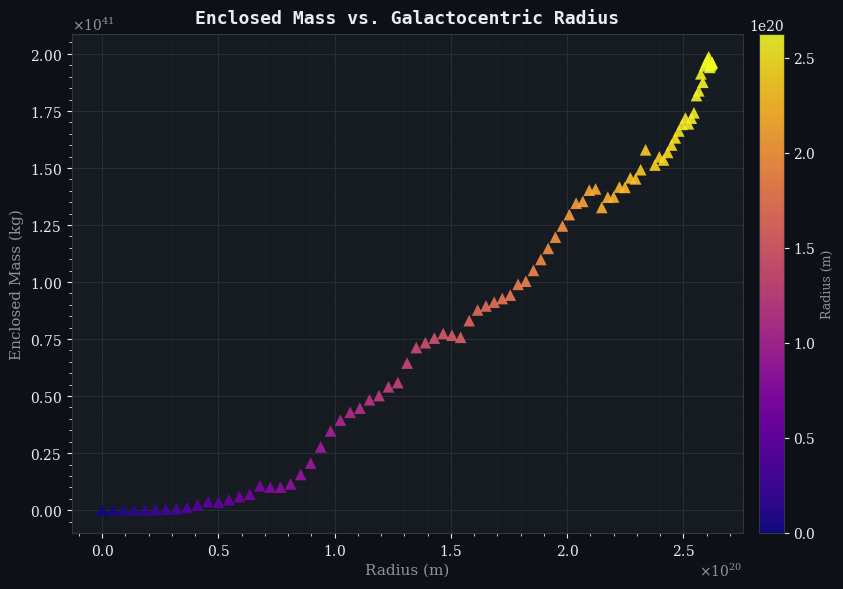

In [383]:

def _style_ax(ax, title):
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=TEXT_COLOR, which='both', labelsize=10)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_COLOR)
    ax.grid(which='major', color=GRID_COLOR, linewidth=0.6, alpha=0.8)
    ax.grid(which='minor', color=GRID_COLOR, linewidth=0.3, alpha=0.4)
    ax.set_title(title, color=TEXT_COLOR, fontsize=13, fontweight='bold',
                 fontfamily='monospace', pad=8)


# ── Plot 1 – Single longitude spectrum ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(DARK_BG)
_style_ax(ax, f"Longitude {plt_long}  —  Intensity vs. Frequency")

ax.plot(temp['Frequency'], temp[plt_long],
        color='#4a9eff', linewidth=1.4, label="Raw intensity")

cutoff = highest_freq_df.loc[
    highest_freq_df['Longitude'] == plt_long, 'Highest_freq'].iloc[0]
ax.axvline(cutoff, color=PEAK_C, linestyle='--', linewidth=1.8,
           label=f"Peak edge  {cutoff:.3f} MHz")

ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Intensity (K)")
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'Images/Long{plt_long}.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()


# ── Plot 2 – Galactic rotation curve ─────────────────────────────────────────
R0 = 8500       # pc
V0 = 220        # km/s
f0 = 1420.40575177  # MHz
c  = 299792.458     # km/s

l_rad = np.deg2rad(highest_freq_df['Longitude'])
v_lsr = c * ((f0 - highest_freq_df['Highest_freq']) / highest_freq_df['Highest_freq'])
R = R0 * np.abs(np.sin(l_rad))
V = v_lsr.to_numpy() + V0 * np.sin(l_rad)

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(DARK_BG)
_style_ax(ax, "Measured Galactic Rotation Curve")

sc = ax.scatter(R, V, marker='*', s=80,
                c=R,                        # colour-encode by radius for depth
                cmap='cool', edgecolors='none', alpha=0.9, zorder=3)
cbar = fig.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label("Galactocentric Radius (pc)", color=MUTED, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR)

ax.set_xlabel("Galactocentric Radius  R  (pc)")
ax.set_ylabel("Rotation Speed  V(R)  (km/s)")

plt.tight_layout()
plt.savefig('Images/GalacticRotation.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()


# ── Plot 3 – Enclosed mass vs radius ─────────────────────────────────────────
G   = 6.67e-11
pc  = 3.086e16
R_m = R * pc
V_ms= V * 1000
m_gal = (V_ms**2 * R_m) / G

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(DARK_BG)
_style_ax(ax, "Enclosed Mass vs. Galactocentric Radius")

sc2 = ax.scatter(R_m, m_gal, marker='^', s=70,
                 c=R_m,
                 cmap='plasma', edgecolors='none', alpha=0.9, zorder=3)
cbar2 = fig.colorbar(sc2, ax=ax, pad=0.02)
cbar2.set_label("Radius (m)", color=MUTED, fontsize=9)
cbar2.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR)

# Scientific notation on both axes for large numbers
ax.xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))
ax.xaxis.get_offset_text().set_color(MUTED)
ax.yaxis.get_offset_text().set_color(MUTED)

ax.set_xlabel("Radius (m)")
ax.set_ylabel("Enclosed Mass (kg)")

plt.tight_layout()
plt.savefig('Images/MassVRadius.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()

In [384]:
spectra=pd.DataFrame()
spectra=temp.copy()

spectra.drop('Frequency',inplace=True,axis=1)
spectra.set_index('Velocity',drop=True,inplace=True)
vel_axis=temp['Velocity']

intensity_cols = [c for c in temp.columns if c in [i for i in range(0,91)]]
spectra = temp[intensity_cols].to_numpy()


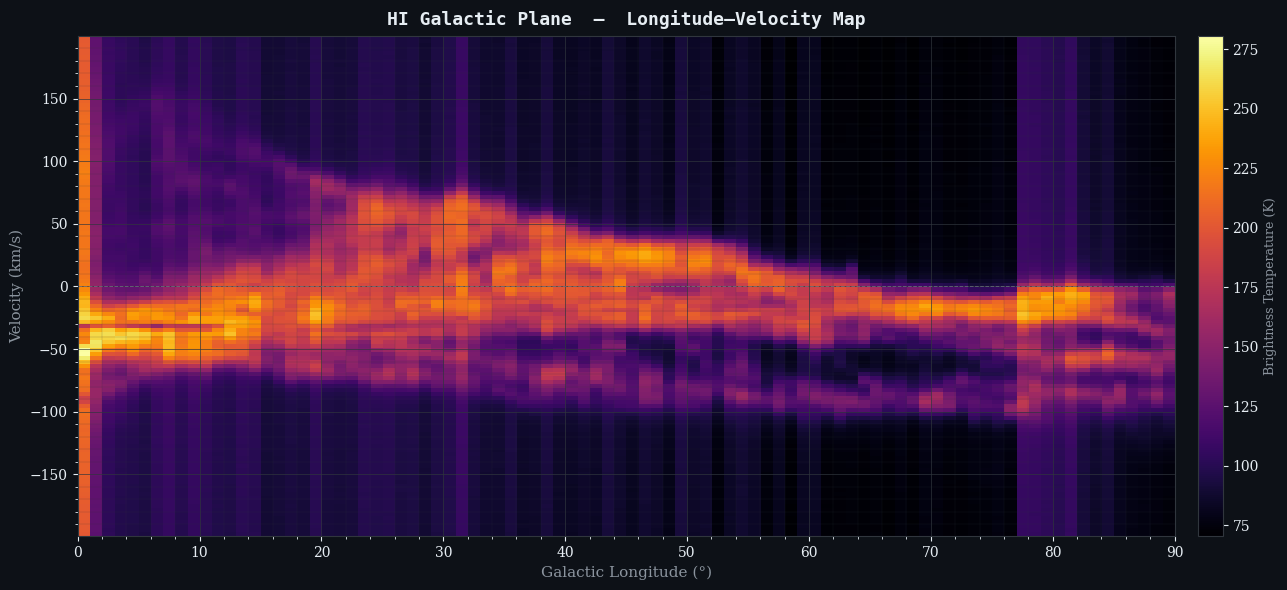

In [385]:
vel_mask     = (vel_axis >= -200) & (vel_axis <= 200)
vel_axis_zoom= vel_axis[vel_mask]
spectra_zoom = spectra[vel_mask]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(DARK_BG)
_style_ax(ax, "HI Galactic Plane  —  Longitude–Velocity Map")

im = ax.imshow(
    spectra_zoom,
    aspect='auto',
    origin='upper',
    extent=[0, 90, vel_axis_zoom.min(), vel_axis_zoom.max()],
    cmap='inferno',         # more vivid than viridis on dark backgrounds
    interpolation='nearest'
)

cbar3 = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.03)
cbar3.set_label("Brightness Temperature (K)", color=MUTED, fontsize=9)
cbar3.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR)

ax.set_xlabel("Galactic Longitude (°)")
ax.set_ylabel("Velocity (km/s)")
ax.axhline(0, color=MUTED, linewidth=0.7, linestyle='--', alpha=0.5)  # zero-vel guide

plt.tight_layout()
plt.savefig('Images/RawLongVel.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()

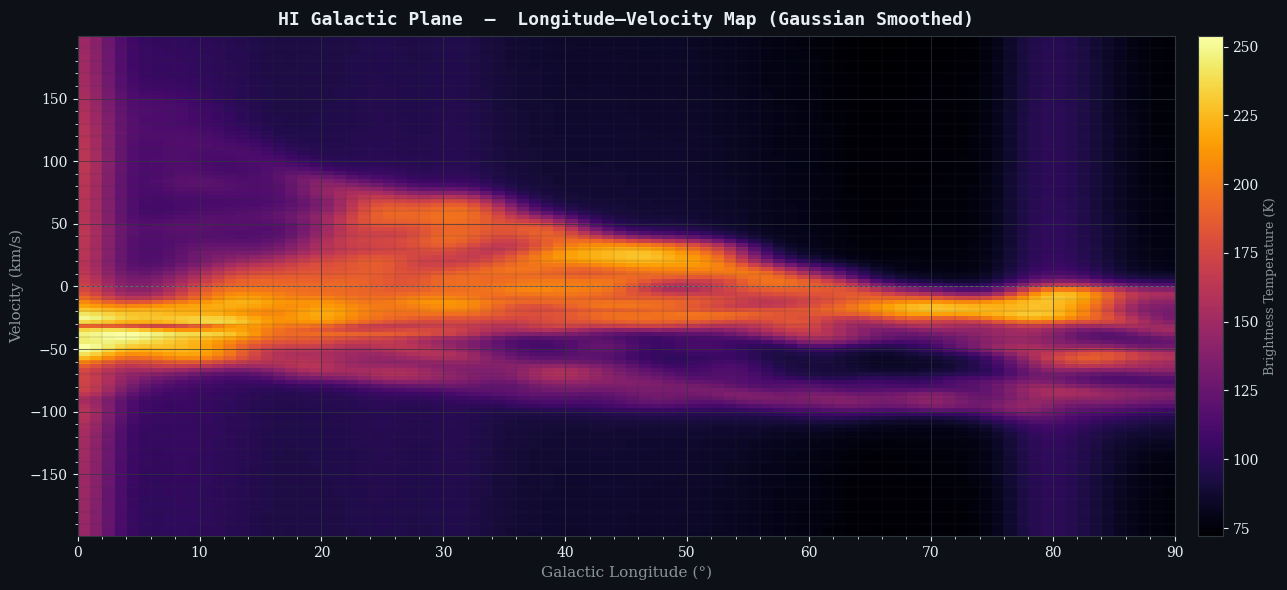

In [386]:
##Smoothed Graphs##

smoothed_intensities=gaussian_filter1d(spectra,2)

vel_mask = (vel_axis >= -200) & (vel_axis <= 200)
vel_axis_zoom = vel_axis[vel_mask]
spectra_zoom = smoothed_intensities[vel_mask]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(DARK_BG)
_style_ax(ax, "HI Galactic Plane  —  Longitude–Velocity Map (Gaussian Smoothed)")

im = ax.imshow(
    spectra_zoom,
    aspect='auto',
    origin='upper',
    extent=[0, 90, vel_axis_zoom.min(), vel_axis_zoom.max()],
    cmap='inferno',         # more vivid than viridis on dark backgrounds
    interpolation='nearest'
)

cbar3 = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.03)
cbar3.set_label("Brightness Temperature (K)", color=MUTED, fontsize=9)
cbar3.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR)

ax.set_xlabel("Galactic Longitude (°)")
ax.set_ylabel("Velocity (km/s)")
ax.axhline(0, color=MUTED, linewidth=0.7, linestyle='--', alpha=0.5)  # zero-vel guide

plt.tight_layout()
plt.savefig('Images/Gaussian.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()


In [387]:
###Univariate Spline Interpolation###

from scipy.interpolate import UnivariateSpline
import numpy as np

vel = temp.index.to_numpy()   # velocity axis from DataFrame index

smoothed_df = temp.copy()     # same shape, smoothed intensities

for col in temp.columns:
    I = temp[col].to_numpy()

    # Fit smoothing spline
    spl = UnivariateSpline(vel, I, s=len(vel))  # s controls smoothing strength

    # Evaluate spline on the same velocity grid
    smoothed_df[col] = spl(vel)


In [388]:
spectra=pd.DataFrame()
spectra=smoothed_df.copy()

spectra.drop('Frequency',inplace=True,axis=1)
spectra.set_index('Velocity',drop=True,inplace=True)
vel_axis=temp['Velocity']

intensity_cols = [c for c in temp.columns if c in [i for i in range(0,91)]]
spectra = smoothed_df[intensity_cols].to_numpy()


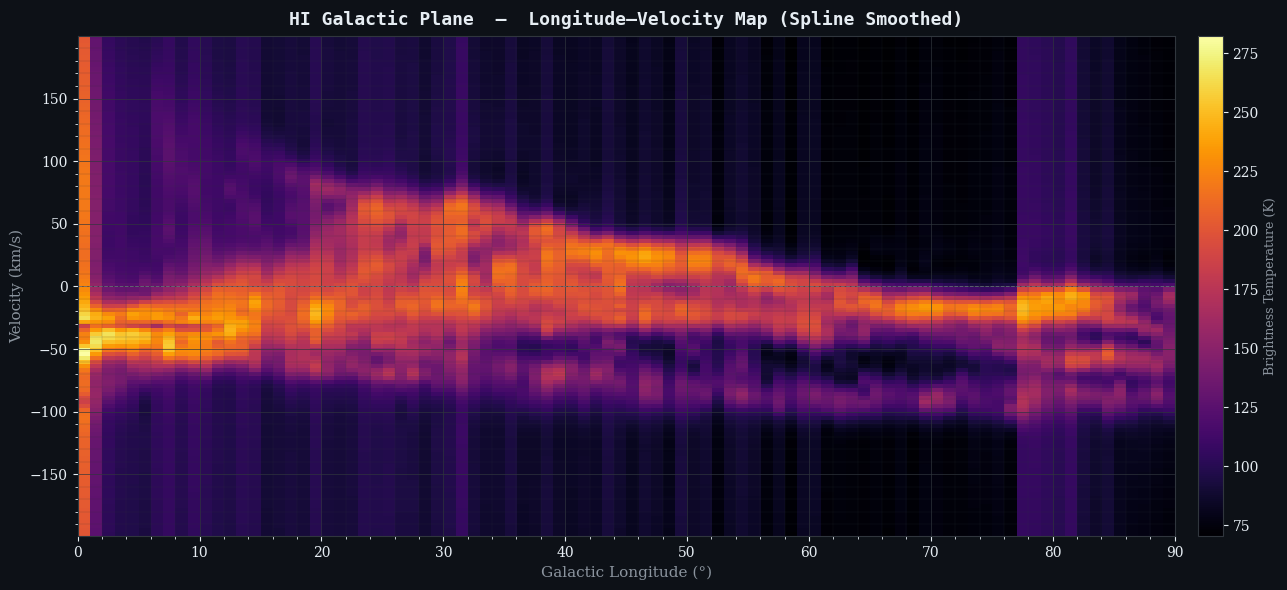

In [389]:
##Smoothed Graphs##


vel_mask = (vel_axis >= -200) & (vel_axis <= 200)
vel_axis_zoom = vel_axis[vel_mask]
spectra_zoom = spectra[vel_mask]

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(DARK_BG)
_style_ax(ax, "HI Galactic Plane  —  Longitude–Velocity Map (Spline Smoothed)")

im = ax.imshow(
    spectra_zoom,
    aspect='auto',
    origin='upper',
    extent=[0, 90, vel_axis_zoom.min(), vel_axis_zoom.max()],
    cmap='inferno',         # more vivid than viridis on dark backgrounds
    interpolation='nearest'
)

cbar3 = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.03)
cbar3.set_label("Brightness Temperature (K)", color=MUTED, fontsize=9)
cbar3.ax.yaxis.set_tick_params(color=TEXT_COLOR, labelcolor=TEXT_COLOR)

ax.set_xlabel("Galactic Longitude (°)")
ax.set_ylabel("Velocity (km/s)")
ax.axhline(0, color=MUTED, linewidth=0.7, linestyle='--', alpha=0.5)  # zero-vel guide

plt.tight_layout()
plt.savefig('Images/Spline.png', dpi=300,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
